# Pose Extraction — Exploration

Interactive scratchpad for working out the extraction pipeline before promoting it to `src/extract_poses.py`. Use this to:

- Eyeball MediaPipe output on individual frames
- Find the right **contact frame** for a video
- Sanity-check joint positions (especially wrist, which the racquet often occludes)
- Tune `min_pose_detection_confidence` if the model is missing frames

**Run from project root** (so the relative paths to `data/raw/...` work):

```bash
cd ~/repos/projects/tennis-stroke-comparison
source .venv/bin/activate
jupyter notebook notebooks/explore_extraction.ipynb
```

**Prerequisite:** the pose model file must be downloaded to `models/pose_landmarker_heavy.task`. From project root:

```bash
mkdir -p models
curl -L -o models/pose_landmarker_heavy.task \
  https://storage.googleapis.com/mediapipe-models/pose_landmarker/pose_landmarker_heavy/float16/latest/pose_landmarker_heavy.task
```

In [3]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision
import matplotlib.pyplot as plt
from pathlib import Path

VIDEO_PATH = Path("../data/raw/murray_fh.mp4")  # change me
MODEL_PATH = Path("../models/pose_landmarker_heavy.task")

assert VIDEO_PATH.exists(), f"Video not found: {VIDEO_PATH}"
assert MODEL_PATH.exists(), (
    f"Model not found: {MODEL_PATH}\n"
    "Download it with:\n"
    "  mkdir -p models\n"
    "  curl -L -o models/pose_landmarker_heavy.task \\\n"
    "    https://storage.googleapis.com/mediapipe-models/pose_landmarker/"
    "pose_landmarker_heavy/float16/latest/pose_landmarker_heavy.task"
)

## 1. Inspect the video

Get fps, dimensions, and total frame count. fps matters because it sets your time resolution — at 30fps each frame is ~33ms, at 120fps each frame is ~8ms.

In [4]:
cap = cv2.VideoCapture(str(VIDEO_PATH))
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

print(f"{width}x{height} @ {fps:.1f} fps, {total} frames ({total/fps:.2f} sec)")

1920x1080 @ 30.0 fps, 501 frames (16.70 sec)


## 2. Scrub through frames to find the contact frame

Change `frame_idx` and re-run the cell. The contact frame is the moment the racquet meets the ball.

**Tip:** binary-search style. Try a frame in the middle. If contact has already happened, go earlier. If it hasn't, go later. You'll converge in ~5 tries.

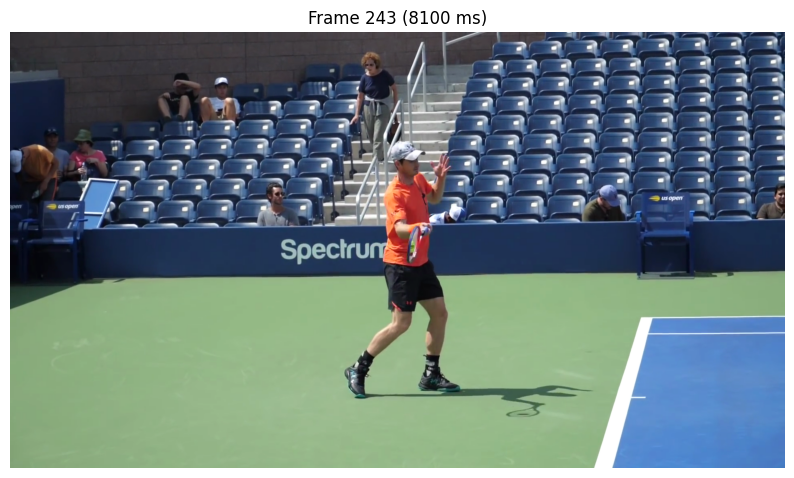

In [7]:
frame_idx = 243  # change me

cap = cv2.VideoCapture(str(VIDEO_PATH))
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
ok, frame = cap.read()
cap.release()
assert ok, f"Could not read frame {frame_idx}"

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title(f"Frame {frame_idx} ({frame_idx/fps*1000:.0f} ms)")
plt.axis('off')
plt.show()

## 3. Run MediaPipe Pose on a single frame

Verify the model finds joints sensibly before running on the whole video. If the skeleton looks wrong here, no point processing 200 frames.

Note: we use `RunningMode.IMAGE` here for one-off frames. The production script uses `RunningMode.VIDEO` for full-video processing, which enables temporal smoothing across frames.

In [8]:
base_options = mp_python.BaseOptions(model_asset_path=str(MODEL_PATH))
options = mp_vision.PoseLandmarkerOptions(
    base_options=base_options,
    running_mode=mp_vision.RunningMode.IMAGE,
    num_poses=1,
    min_pose_detection_confidence=0.5,
)

with mp_vision.PoseLandmarker.create_from_options(options) as landmarker:
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
    result = landmarker.detect(mp_image)

if not result.pose_landmarks:
    print("No pose detected. Try lowering min_pose_detection_confidence to 0.3.")
else:
    print(f"Pose detected. {len(result.pose_landmarks[0])} landmarks found.")
    landmarks = result.pose_landmarks[0]
    # Sample a few joints
    for name, idx in [("left shoulder", 11), ("right wrist", 16), ("left hip", 23)]:
        lm = landmarks[idx]
        print(f"  {name}: ({lm.x*width:.0f}, {lm.y*height:.0f}) vis={lm.visibility:.2f}")

I0000 00:00:1778001344.418665 5168493 init-domain.cc:128] Fiber init: default domain = pthread, concurrency = 8, prefix = pthread-default
I0000 00:00:1778001344.586842 5168493 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1778001344.643687 5168495 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778001344.728954 5168495 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778001344.814087 5168502 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


Pose detected. 33 landmarks found.
  left shoulder: (1012, 376) vis=1.00
  right wrist: (1001, 488) vis=0.89
  left hip: (1015, 584) vis=1.00


## 4. Visualize the detected skeleton

Overlay the skeleton on the frame. This is the visual sanity check — if the lines look like a person, the extraction is working. If joints are off (e.g. wrist on the racquet head instead of the actual wrist), you'll see it here.

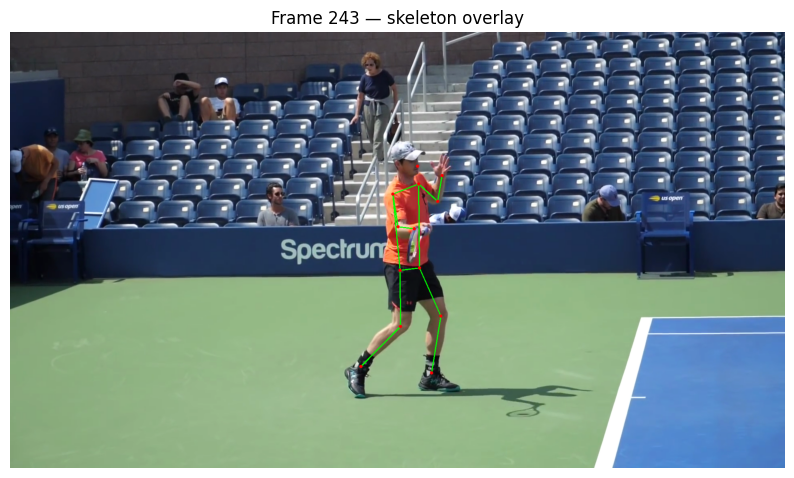

In [9]:
import sys
sys.path.insert(0, '../src')
from extract_poses import extract_landmarks, draw_skeleton

if result.pose_landmarks:
    joints = extract_landmarks(result.pose_landmarks[0], width, height)
    annotated = frame.copy()
    draw_skeleton(annotated, joints)
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title(f"Frame {frame_idx} — skeleton overlay")
    plt.axis('off')
    plt.show()

## 5. When you're satisfied with the contact frame

Run the production script from a terminal (in your second tab, with the venv activated):

```bash
python src/extract_poses.py data/raw/murray_fh.mp4 \
    --contact-frame 250 \
    --player murray \
    --debug-video
```

The `--debug-video` flag writes a `.debug.mp4` next to the JSON so you can scrub through and verify the skeleton tracks correctly across all frames, not just this one.